In [1]:
import random
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

In [2]:
from pocketgrad import nn
from pocketgrad.engine import Scalar

In [3]:
np.random.seed(1337)  # for shuffling
random.seed(1337)     # for weights and biases

In [4]:
# Get toy dataset
from sklearn.datasets import make_moons, make_blobs

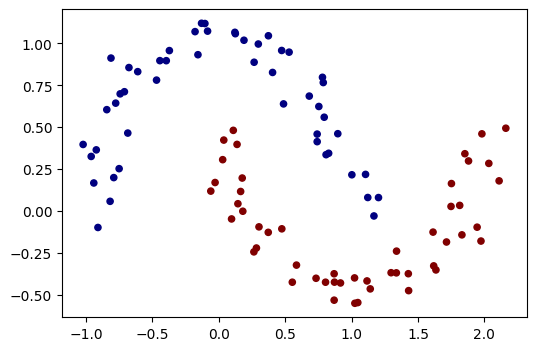

In [5]:
# Prepare the dataset
X, y = make_moons(n_samples=100, noise=0.1)

y = y * 2 - 1  # make y be -1 or 1

# Visualize in 2D
plt.figure(figsize=(6, 4))
plt.scatter(X[:, 0], X[:, 1], c=y, s=20, cmap="jet")

In [6]:
# Initialize the model
model = nn.MLP(2, [16, 16, 1])
print(model)
print("\nTotal trainable parameters: ", len(model.parameters()))

MLP of [Layer of [ReLUNeuron(2), ReLUNeuron(2), ReLUNeuron(2), ReLUNeuron(2), ReLUNeuron(2), ReLUNeuron(2), ReLUNeuron(2), ReLUNeuron(2), ReLUNeuron(2), ReLUNeuron(2), ReLUNeuron(2), ReLUNeuron(2), ReLUNeuron(2), ReLUNeuron(2), ReLUNeuron(2), ReLUNeuron(2)], Layer of [ReLUNeuron(16), ReLUNeuron(16), ReLUNeuron(16), ReLUNeuron(16), ReLUNeuron(16), ReLUNeuron(16), ReLUNeuron(16), ReLUNeuron(16), ReLUNeuron(16), ReLUNeuron(16), ReLUNeuron(16), ReLUNeuron(16), ReLUNeuron(16), ReLUNeuron(16), ReLUNeuron(16), ReLUNeuron(16)], Layer of [LinearNeuron(16)]]

Total trainable parameters:  337


In [7]:
def compute_loss(batch_size=None):
    """
    Compute the SVM-style hinge loss with L2 regularization.
    """
    
    # Use the full dataset or sample a random minibatch
    if batch_size is None:
        Xb, yb = X, y
    else:
        indices = np.random.permutation(X.shape[0])[:batch_size]
        Xb, yb = X[indices], y[indices]

    # Convert raw inputs to Scalar objects
    inputs = [list(map(Scalar, row)) for row in Xb]

    # Run the model to get decision scores
    scores = list(map(model, inputs))

    # SVM "max-margin" loss (aka hinge loss)
    losses = [(1 + -yi * score_i).relu() for yi, score_i in zip(yb, scores)]
    data_loss = sum(losses) * (1.0 / len(losses))
    
    # L2 regularization to prevent overfitting
    # Note: The usual 1/2 factor is skipped to match micrograd convention.
    lambda_param = 1e-4  
    reg_loss = lambda_param * sum((p * p for p in model.parameters()))
    total_loss = reg_loss + data_loss

    # Predict by score sign and compare with label sign
    accuracy = [(yi > 0) == (score_i.data > 0) for yi, score_i in zip(yb, scores)]
    return total_loss, sum(accuracy) / len(accuracy)

In [8]:
# Train the model
epochs = 100

for epoch in range(epochs):

    # Forward pass
    total_loss, acc = compute_loss()

    # Backward pass
    model.zero_grad()
    total_loss.backward()

    # SGD with learning rate decay
    learning_rate = 1.0 - 0.9 * epoch / 100
    for p in model.parameters():
        p.data -= learning_rate * p.grad

    print(f"Epoch [{epoch+1}/{epochs}], Loss: {total_loss.data:.4f}, Accuracy: {acc * 100:.2f}%")

Epoch [1/100], Loss: 0.8958, Accuracy: 50.00%
Epoch [2/100], Loss: 1.7236, Accuracy: 81.00%
Epoch [3/100], Loss: 0.7429, Accuracy: 77.00%
Epoch [4/100], Loss: 0.7706, Accuracy: 82.00%
Epoch [5/100], Loss: 0.3693, Accuracy: 84.00%
Epoch [6/100], Loss: 0.3135, Accuracy: 86.00%
Epoch [7/100], Loss: 0.2814, Accuracy: 89.00%
Epoch [8/100], Loss: 0.2689, Accuracy: 91.00%
Epoch [9/100], Loss: 0.2567, Accuracy: 91.00%
Epoch [10/100], Loss: 0.2705, Accuracy: 91.00%
Epoch [11/100], Loss: 0.2451, Accuracy: 91.00%
Epoch [12/100], Loss: 0.2510, Accuracy: 92.00%
Epoch [13/100], Loss: 0.2156, Accuracy: 91.00%
Epoch [14/100], Loss: 0.2309, Accuracy: 93.00%
Epoch [15/100], Loss: 0.2015, Accuracy: 92.00%
Epoch [16/100], Loss: 0.2257, Accuracy: 93.00%
Epoch [17/100], Loss: 0.1945, Accuracy: 92.00%
Epoch [18/100], Loss: 0.2109, Accuracy: 93.00%
Epoch [19/100], Loss: 0.1598, Accuracy: 94.00%
Epoch [20/100], Loss: 0.1845, Accuracy: 93.00%
Epoch [21/100], Loss: 0.1898, Accuracy: 91.00%
Epoch [22/100], Loss: 

(-1.548639298268643, 1.951360701731357)

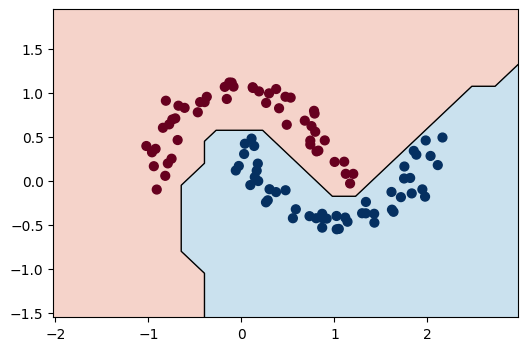

In [9]:
# Visualize decision boundary
h = 0.25
x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h))
Xmesh = np.c_[xx.ravel(), yy.ravel()]
inputs = [list(map(Scalar, row)) for row in Xmesh]
scores = list(map(model, inputs))
Z = np.array([s.data > 0 for s in scores])
Z = Z.reshape(xx.shape)

plt.figure(figsize=(6, 4))
plt.contourf(xx, yy, Z, cmap="RdBu", alpha=0.35)
plt.contour(xx, yy, Z, levels=[0.5], colors="k", linewidths=1)
plt.scatter(X[:, 0], X[:, 1], c=y, s=40, cmap="RdBu")
plt.xlim(xx.min(), xx.max())
plt.ylim(yy.min(), yy.max())